<a href="https://colab.research.google.com/github/mailnami-coder/Learn-ML-Basics/blob/main/PCA_Coffee_Bean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Explained Variance Ratio ---
[0.99766091 0.00141821]

--- Feature Loadings (The Component Weights) ---
                 PC1       PC2
Size_mm     0.499864  0.659585
Weight_mg   0.500081  0.267555
Acidity    -0.499921  0.641940
Bitterness  0.500134 -0.285089

--- Final Transformed Bean Scores ---
   PC1_Build  PC2_Flavor
0  -2.257830    0.011013
1   2.451490    0.138757
2  -2.604740    0.033921
3   2.452550   -0.090955
4   0.112927   -0.068034
5  -0.154398   -0.024702


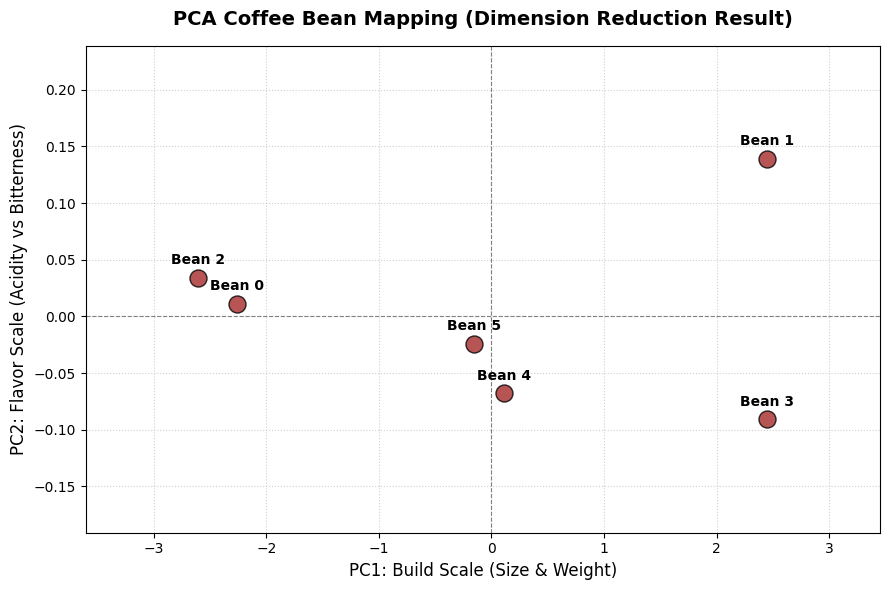

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Create the Raw Mock Dataset
# Columns: [Size (mm), Weight (mg), Acidity (1-10), Bitterness (1-10)]
data = {
    "Size_mm": [4.2, 8.1, 4.0, 7.9, 6.0, 5.8],
    "Weight_mg": [150.0, 250.0, 140.0, 245.0, 200.0, 195.0],
    "Acidity": [8.5, 3.1, 9.0, 2.8, 5.5, 6.0],
    "Bitterness": [2.1, 7.9, 1.8, 8.2, 5.0, 4.8],
}
df = pd.DataFrame(data)
bean_labels = [f"Bean {i}" for i in range(len(df))]

# 2. Standardize the Features (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. Fit the PCA Model (Reduce 4 dimensions down to 2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a clean DataFrame of our new coordinates
df_transformed = pd.DataFrame(X_pca, columns=["PC1_Build", "PC2_Flavor"])

# 4. Print the Machine Learning Metrics to Console
print("--- Explained Variance Ratio ---")
print(pca.explained_variance_ratio_)

print("\n--- Feature Loadings (The Component Weights) ---")
loadings = pd.DataFrame(
    pca.components_.T, columns=["PC1", "PC2"], index=df.columns
)
print(loadings)

print("\n--- Final Transformed Bean Scores ---")
print(df_transformed)

# 5. Plot the Exact Results Using Matplotlib
plt.figure(figsize=(9, 6))

# Extract PC1 and PC2 coordinates from our transformed array
pc1_coords = X_pca[:, 0]
pc2_coords = X_pca[:, 1]

# Draw the scatter points
plt.scatter(
    pc1_coords,
    pc2_coords,
    color="brown",
    s=150,
    zorder=5,
    edgecolor="black",
    alpha=0.8,
)

# Overlay text labels above each point
for i, label in enumerate(bean_labels):
    plt.annotate(
        label,
        (pc1_coords[i], pc2_coords[i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        weight="bold",
    )

# Draw central axis crosshairs at (0,0)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)

# Customize graph aesthetics
plt.title(
    "PCA Coffee Bean Mapping (Dimension Reduction Result)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("PC1: Build Scale (Size & Weight)", fontsize=12)
plt.ylabel("PC2: Flavor Scale (Acidity vs Bitterness)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)

# Provide safety margins on the edges of the plot
plt.xlim(min(pc1_coords) - 1, max(pc1_coords) + 1)
plt.ylim(min(pc2_coords) - 0.1, max(pc2_coords) + 0.1)

# Render layout and display the window
plt.tight_layout()
plt.show()